In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data

from scipy.stats import spearmanr, pearsonr

In [2]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Time analysis specific colors
COLOR_EXPECTED = '#87CEEB'    # Light blue for expected time
COLOR_FAST = '#FFD700'        # Yellow for faster than expected (< 85%)
COLOR_SLOW = '#FF4444'        # Red for slower than expected (> 115%)

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Time comparison colors
TIME_COLORS = {
    'expected': COLOR_EXPECTED,
    'fast': COLOR_FAST,
    'slow': COLOR_SLOW,
    'normal_combined': COLOR_COMBINED,
    'normal_male': COLOR_MALE,
    'normal_female': COLOR_FEMALE
}

# Detailed analysis of time during the exam. expexted time vs. time taken task by task + by gender. see if time taken by task affects performance during each task.

In this part we performe the analysis only on students without extra or incident time.

## 1. Data Loading

In [3]:
df = load_data("../data/cleaned_data/IN2120_2024_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN2120_2024_cleaned_data.csv


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,final_grade_date,final_grade,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_1370871167225,konfidensialitet,67.5
1,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA17313295674742d674d25-c722-4a92...,tilgjengelighet,67.5
2,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA173132962912484243f1a-833f-47fb...,integritet,67.5
3,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_IA173100234618194d062e4...,simpleAssociableChoice_IA173100234618194d062e4...,67.5
4,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_1373281683440 simpleAss...,simpleAssociableChoice_1373281683440 simpleAss...,67.5


## 2. Data Preparation

In [4]:
df_time = df.groupby(['student_id', 'question_number']).agg({
    'gender': 'first',
    'max_question_score': 'first',
    'auto_score_per_question': 'first',
    'question_duration_sec': 'first',
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first',
    'total_score': 'first'
}).reset_index()
df_time = df_time[df_time['question_number'] != 8.1]  # Remove question 8.1 if it's not relevant

df_time['time_taken_exam_min'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.drop(columns=['exam_start_time', 'exam_end_time'])

df_time['expected_time_per_question_sec'] = 144 * df_time['max_question_score']  # Assuming 144 sec (2.4 minutes) per point since total exam time is 240 minutes for 100 points

df_time.head()

,student_id,question_number,gender,max_question_score,auto_score_per_question,question_duration_sec,extra_time_mins,incident_time_mins,total_score,time_taken_exam_min,expected_time_per_question_sec
0,1,1.10,M,3,3.0,38,0,0,45.0,105.57,432
1,1,1.11,M,1,1.0,49,0,0,45.0,105.57,144
2,1,1.12,M,3,1.0,181,0,0,45.0,105.57,432
3,1,1.13,M,3,2.0,31,0,0,45.0,105.57,432
4,1,1.20,M,2,2.0,31,0,0,45.0,105.57,288


## 3. Data exploration

In [5]:
extra_time_students_data = df_time[(df_time['extra_time_mins'] != 0) | (df_time['incident_time_mins'] != 0)]

extra_time_students_count = extra_time_students_data.groupby('student_id').agg({
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

counter1 = 0
counter2 = 0

for i in extra_time_students_count['extra_time_mins']:
    if i != 0:
        counter1 += 1

for i in extra_time_students_count['incident_time_mins']:
    if i != 0:
        counter2 += 1

print(f"There are {counter1} students with extra_time_mins (given before the exam).")
print(f"There are {counter2} students with incident_time_mins (given during the exam).")

There are 0 students with extra_time_mins (given before the exam).
There are 1 students with incident_time_mins (given during the exam).


In [6]:
# remove students with extra time or incident time
df_time = df_time[(df_time['extra_time_mins'] == 0) & (df_time['incident_time_mins'] == 0)]

In [7]:
# checking
# print("After filtering:")
# print(f"Students with extra_time_mins != 0: {len(df_time[df_time['extra_time_mins'] != 0])}")
# print(f"Students with incident_time_mins != 0: {len(df_time[df_time['incident_time_mins'] != 0])}")
# print(f"Total students remaining: {df_time['student_id'].nunique()}")

In [8]:
# description and exploration of spesific columns in df_time
df_time[['time_taken_exam_min']].describe()

,time_taken_exam_min
count,13176.000000
mean,139.309262
std,49.476678
min,44.470000
25%,101.100000
50%,128.100000
75%,175.480000
max,270.530000


=== TIME OUTLIER ANALYSIS ===
Combined Time: 0 outliers (0.0%)
Male Time: 0 outliers (0.0%)
Female Time: 0 outliers (0.0%)


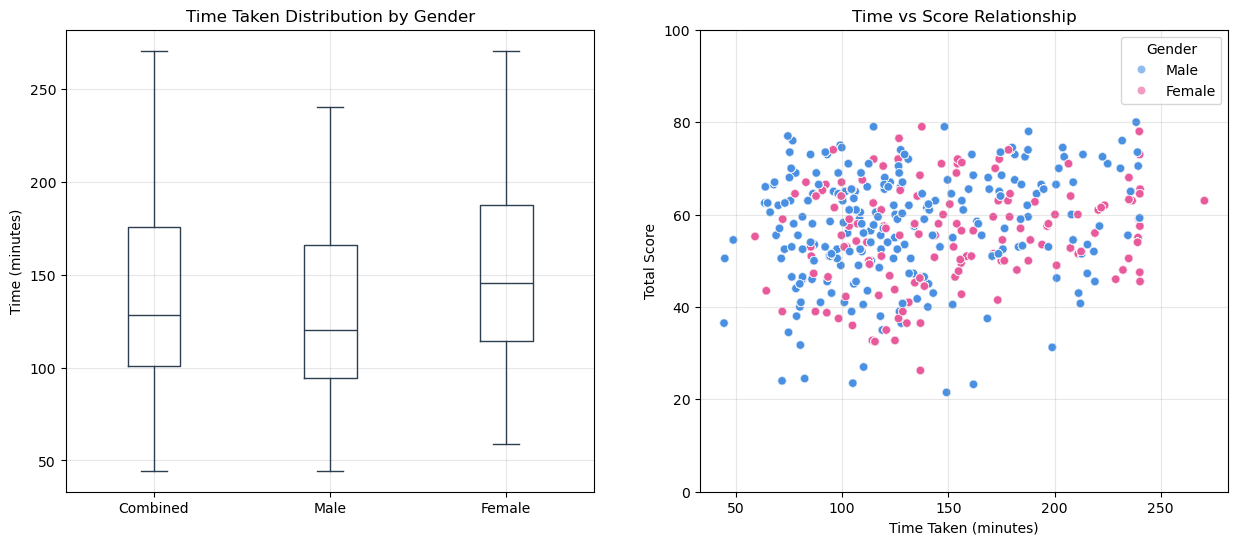

Correlation between Time Taken and Total Score:
                     time_taken_exam_min  total_score
time_taken_exam_min             1.000000     0.181355
total_score                     0.181355     1.000000

Correlation coefficient: 0.1814

Interpretation:
• Weak correlation - slight linear relationship
• Positive relationship: longer exam time tends to associate with higher scores


<Figure size 640x480 with 0 Axes>

In [9]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_outliers = pd.DataFrame({
    'Combined': df_time['time_taken_exam_min'],
    'Male': df_time[df_time['gender'] == 'M']['time_taken_exam_min'],
    'Female': df_time[df_time['gender'] == 'F']['time_taken_exam_min']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time['time_taken_exam_min'], "Combined Time")
time_male_outliers = identify_outliers(df_time[df_time['gender'] == 'M']['time_taken_exam_min'], "Male Time")
time_female_outliers = identify_outliers(df_time[df_time['gender'] == 'F']['time_taken_exam_min'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time, x='time_taken_exam_min', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# Update legend labels for clarity - map the original labels to proper gender names
handles, labels = axes[1].get_legend_handles_labels()
# Create a mapping from the original labels (F/M) to full names
label_mapping = {'F': 'Female', 'M': 'Male'}
new_labels = [label_mapping.get(label, label) for label in labels]
axes[1].legend(handles, new_labels, title='Gender')

plt.show()
plt.tight_layout()

# ## Correlations
df_corr_time_vs_total_score = df_time.groupby('student_id').agg({
    'time_taken_exam_min': 'first',
    'total_score': 'first'
}).reset_index()

correlation_result = df_corr_time_vs_total_score[['time_taken_exam_min', 'total_score']].corr()
print("Correlation between Time Taken and Total Score:")
print(correlation_result)

# Extract the correlation coefficient
time_score_corr = correlation_result.loc['time_taken_exam_min', 'total_score']

print(f"\nCorrelation coefficient: {time_score_corr:.4f}")
print("\nInterpretation:")
if abs(time_score_corr) < 0.1:
    print("• Very weak correlation - practically no linear relationship")
elif abs(time_score_corr) < 0.3:
    print("• Weak correlation - slight linear relationship")
elif abs(time_score_corr) < 0.5:
    print("• Moderate correlation - noticeable linear relationship")
elif abs(time_score_corr) < 0.7:
    print("• Strong correlation - clear linear relationship")
else:
    print("• Very strong correlation - very clear linear relationship")

if time_score_corr > 0:
    print("• Positive relationship: longer exam time tends to associate with higher scores")
elif time_score_corr < 0:
    print("• Negative relationship: longer exam time tends to associate with lower scores")
else:
    print("• No linear relationship between exam time and scores")



In [10]:
# Spearman correlation analysis between time and score
# The Spearman correlation is particularly useful here because it:

# Measures monotonic relationships (not just linear like Pearson)
# Is more robust to outliers
# Works well with ranked data
# Can detect non-linear but monotonic patterns between exam time and performance


# Calculate Spearman correlation
spearman_corr, spearman_p_value = spearmanr(df_corr_time_vs_total_score['time_taken_exam_min'], 
                                           df_corr_time_vs_total_score['total_score'])

print("=== SPEARMAN CORRELATION ANALYSIS ===")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print(f"P-value: {spearman_p_value:.4f}")

# Interpretation of Spearman correlation
print("\nSpearman Correlation Interpretation:")
if abs(spearman_corr) < 0.1:
    print("• Very weak monotonic relationship")
elif abs(spearman_corr) < 0.3:
    print("• Weak monotonic relationship")
elif abs(spearman_corr) < 0.5:
    print("• Moderate monotonic relationship")
elif abs(spearman_corr) < 0.7:
    print("• Strong monotonic relationship")
else:
    print("• Very strong monotonic relationship")

# Direction interpretation
if spearman_corr > 0:
    print("• Positive monotonic relationship: higher ranks in time tend to associate with higher ranks in scores")
elif spearman_corr < 0:
    print("• Negative monotonic relationship: higher ranks in time tend to associate with lower ranks in scores")
else:
    print("• No monotonic relationship between time ranks and score ranks")

# Statistical significance
alpha = 0.05
if spearman_p_value < alpha:
    print(f"• Statistically significant at α = {alpha} (p < {alpha})")
else:
    print(f"• Not statistically significant at α = {alpha} (p ≥ {alpha})")

=== SPEARMAN CORRELATION ANALYSIS ===
Spearman correlation coefficient: 0.1521
P-value: 0.0035

Spearman Correlation Interpretation:
• Weak monotonic relationship
• Positive monotonic relationship: higher ranks in time tend to associate with higher ranks in scores
• Statistically significant at α = 0.05 (p < 0.05)


In [11]:
# description and exploration of spesific columns in df_time
df_time[['expected_time_per_question_sec', 'question_duration_sec']].describe()

,expected_time_per_question_sec,question_duration_sec
count,13176.000000,13176.000000
mean,360.000000,163.736642
std,177.995518,174.455020
min,144.000000,0.000000
25%,288.000000,54.000000
50%,288.000000,107.000000
75%,432.000000,210.000000
max,864.000000,2644.000000


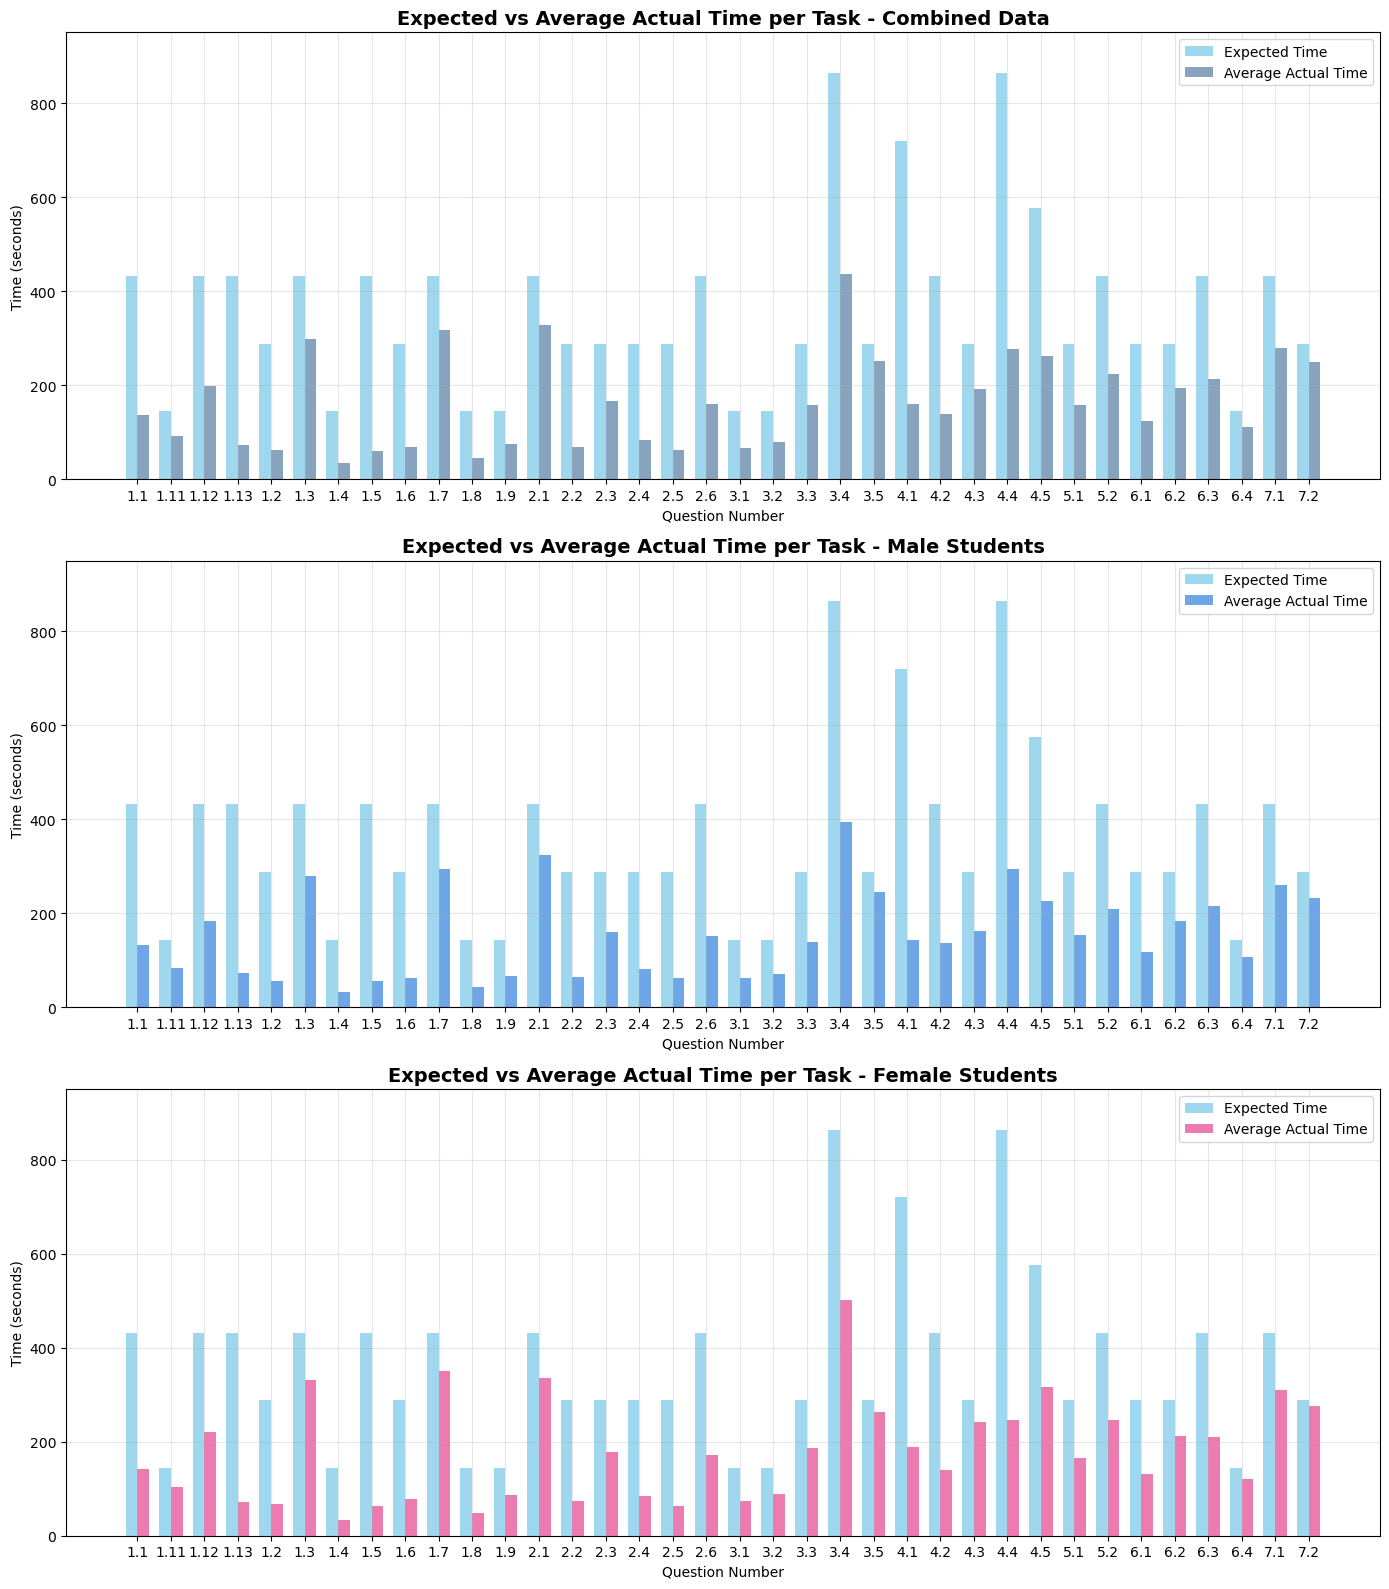

In [12]:
# Bar plots comparing expected vs actual time per task
# Calculate average time per question for each group
time_by_task = df_time.groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',  # Same for all students
    'question_duration_sec': 'mean'  # Average actual time
}).reset_index()

time_by_task_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

time_by_task_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

# Determine the maximum y-axis value for consistent scaling across all plots
max_expected = max(time_by_task['expected_time_per_question_sec'].max(),
                   time_by_task_male['expected_time_per_question_sec'].max(),
                   time_by_task_female['expected_time_per_question_sec'].max())
max_actual = max(time_by_task['question_duration_sec'].max(),
                 time_by_task_male['question_duration_sec'].max(),
                 time_by_task_female['question_duration_sec'].max())
y_max = max(max_expected, max_actual) * 1.1  # Add 10% padding

# Create the three plots
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Plot 1: Combined data
x = time_by_task['question_number']
width = 0.35
x_pos = range(len(x))

bars1 = axes[0].bar([i - width/2 for i in x_pos], time_by_task['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x_pos], time_by_task['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_COMBINED, alpha=0.8)

axes[0].set_xlabel('Question Number')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Expected vs Average Actual Time per Task - Combined Data', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_ylim(0, y_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars2:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 2: Male students
x_male = time_by_task_male['question_number']
x_pos_male = range(len(x_male))

bars3 = axes[1].bar([i - width/2 for i in x_pos_male], time_by_task_male['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars4 = axes[1].bar([i + width/2 for i in x_pos_male], time_by_task_male['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_MALE, alpha=0.8)

axes[1].set_xlabel('Question Number')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Expected vs Average Actual Time per Task - Male Students', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos_male)
axes[1].set_xticklabels(x_male)
axes[1].set_ylim(0, y_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars3:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars4:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 3: Female students
x_female = time_by_task_female['question_number']
x_pos_female = range(len(x_female))

bars5 = axes[2].bar([i - width/2 for i in x_pos_female], time_by_task_female['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars6 = axes[2].bar([i + width/2 for i in x_pos_female], time_by_task_female['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_FEMALE, alpha=0.8)

axes[2].set_xlabel('Question Number')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Expected vs Average Actual Time per Task - Female Students', fontsize=14, fontweight='bold')
axes[2].set_xticks(x_pos_female)
axes[2].set_xticklabels(x_female)
axes[2].set_ylim(0, y_max)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars5:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars6:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

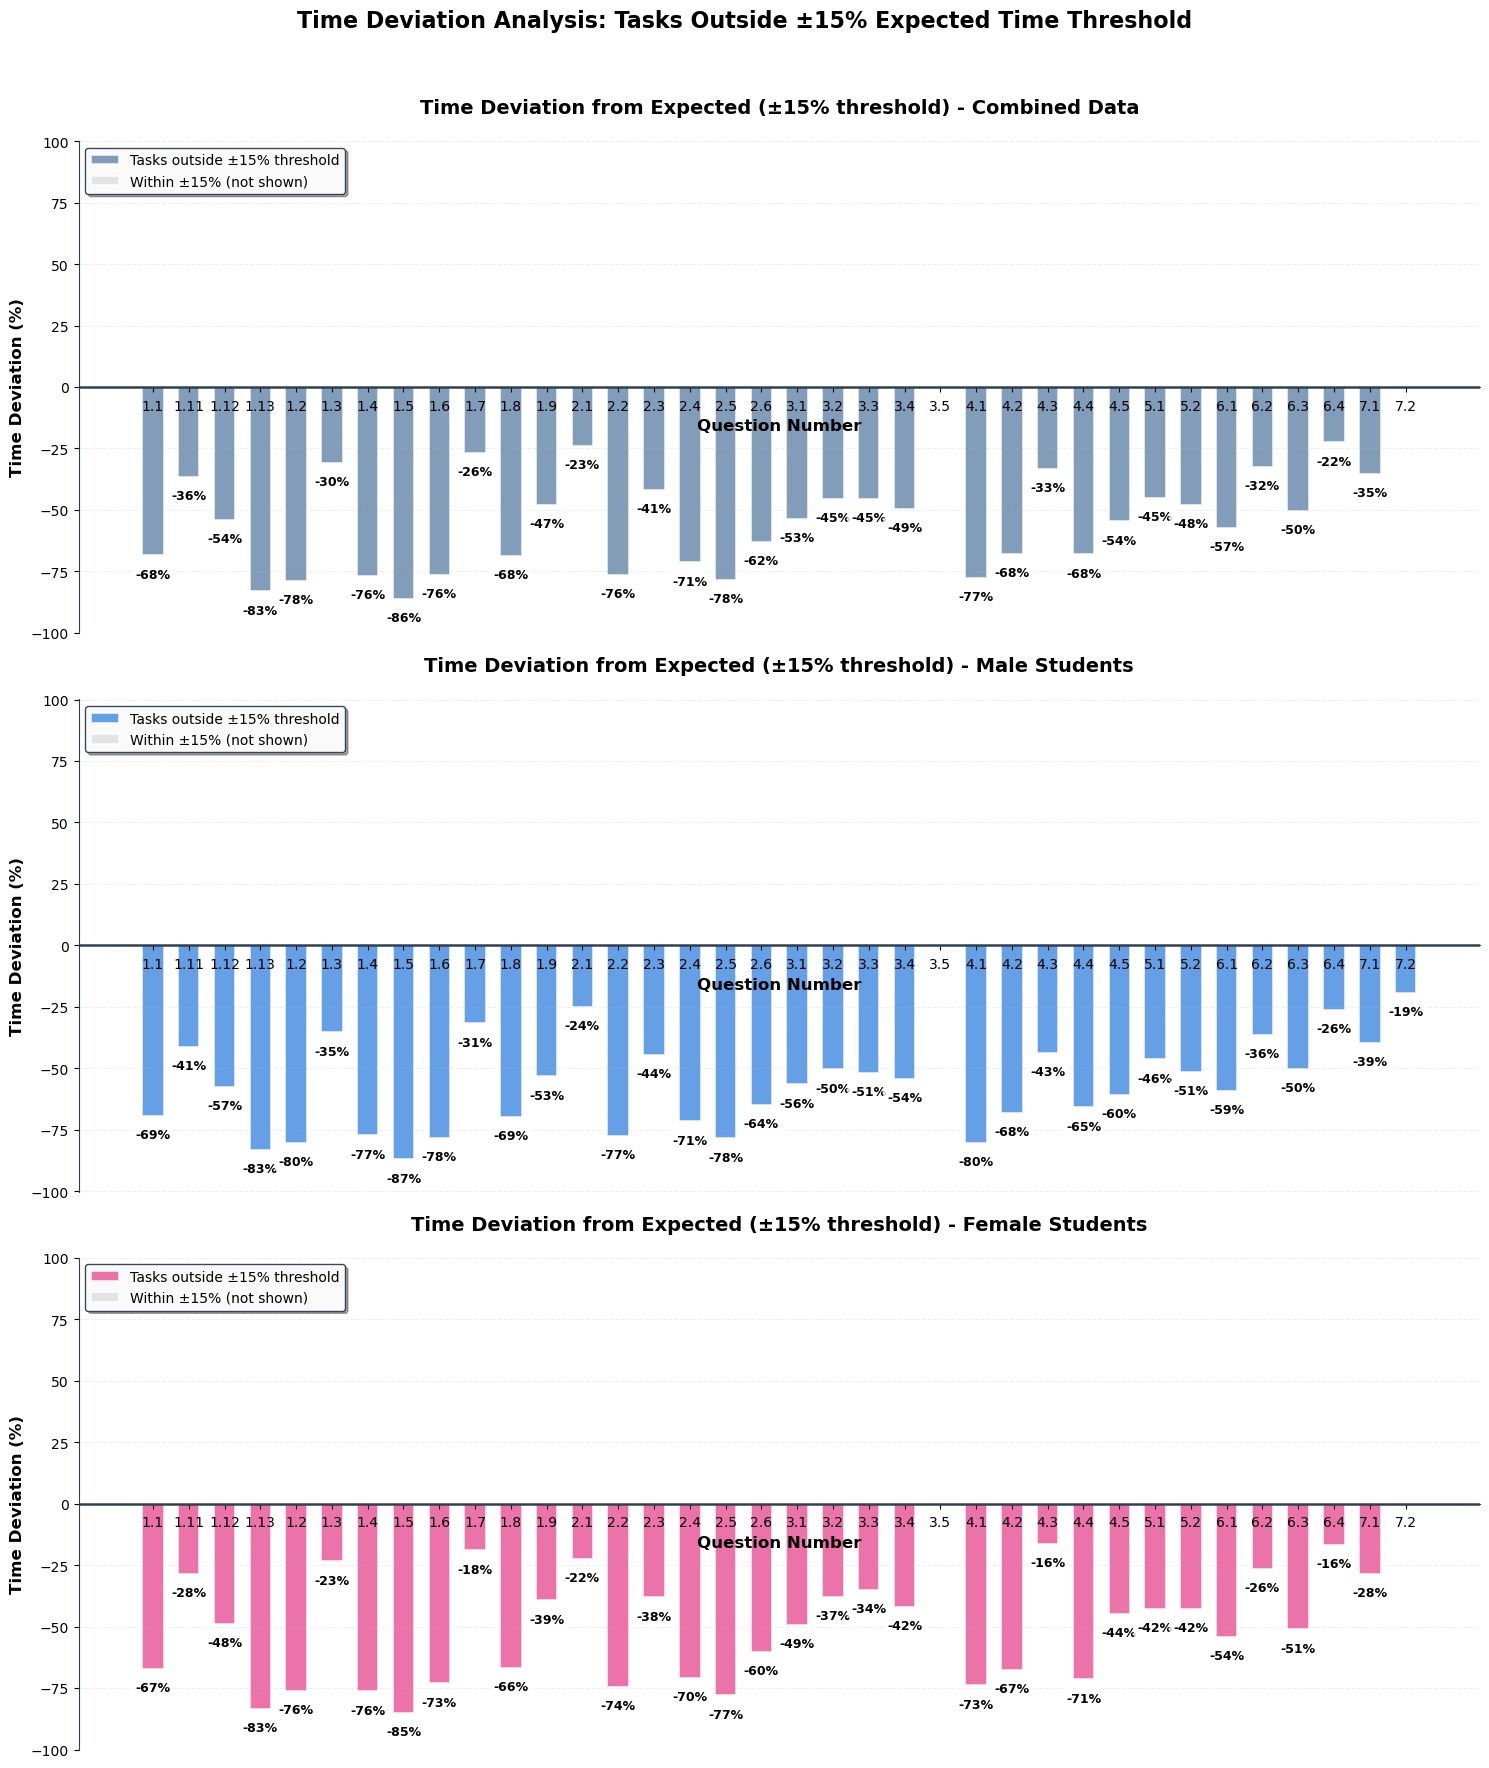


=== TIME DEVIATION SUMMARY ===

Combined Students:
  Tasks outside ±15% threshold: 34/36 (94.4%)
  Tasks taking longer than expected (>15%): 0
  Tasks taking less time than expected (<-15%): 34
    Fastest tasks: 1.5, 1.13, 1.2

Male Students:
  Tasks outside ±15% threshold: 35/36 (97.2%)
  Tasks taking longer than expected (>15%): 0
  Tasks taking less time than expected (<-15%): 35
    Fastest tasks: 1.5, 1.13, 1.2

Female Students:
  Tasks outside ±15% threshold: 34/36 (94.4%)
  Tasks taking longer than expected (>15%): 0
  Tasks taking less time than expected (<-15%): 34
    Fastest tasks: 1.5, 1.13, 2.5


In [13]:
# Time deviation analysis - showing only deviations outside ±15% threshold for expected time taken
# Calculate time deviations for each group
def calculate_time_deviations(data, group_name="Combined"):
    """Calculate time deviations from expected time, only showing values outside ±15% threshold"""
    time_by_task = data.groupby('question_number').agg({
        'expected_time_per_question_sec': 'first',
        'question_duration_sec': 'mean'
    }).reset_index()
    
    # Calculate percentage deviation
    time_by_task['deviation_pct'] = ((time_by_task['question_duration_sec'] - time_by_task['expected_time_per_question_sec']) / 
                                    time_by_task['expected_time_per_question_sec']) * 100
    
    # Calculate absolute deviation in seconds
    time_by_task['deviation_sec'] = time_by_task['question_duration_sec'] - time_by_task['expected_time_per_question_sec']
    
    # Only show deviations outside ±15% threshold (in percentage)
    time_by_task['deviation_pct_filtered'] = time_by_task['deviation_pct'].where(
        (time_by_task['deviation_pct'] < -15) | (time_by_task['deviation_pct'] > 15), 0
    )
    
    return time_by_task

# Calculate deviations for all groups
deviation_combined = calculate_time_deviations(df_time, "Combined")
deviation_male = calculate_time_deviations(df_time[df_time['gender'] == 'M'], "Male")
deviation_female = calculate_time_deviations(df_time[df_time['gender'] == 'F'], "Female")

# Calculate global y-axis limits for consistent scaling
all_deviations = []
for data in [deviation_combined, deviation_male, deviation_female]:
    all_deviations.extend(data['deviation_pct_filtered'].tolist())

max_abs_deviation_global = max(abs(min(all_deviations)), abs(max(all_deviations)))
y_limit_global = max_abs_deviation_global * 1.15

# Create the deviation plots with improved styling
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
fig.suptitle('Time Deviation Analysis: Tasks Outside ±15% Expected Time Threshold', 
             fontsize=16, fontweight='bold', y=0.98)

# Helper function to create deviation bar plot
def create_deviation_plot(ax, data, title, bar_color, y_limit):
    x = data['question_number']
    y = data['deviation_pct_filtered']
    x_pos = range(len(x))  # Use range for positions like in cell 15
    
    # Use single color for all bars (only show bars with deviations outside ±15%)
    colors = [bar_color if val != 0 else '#E0E0E0' for val in y]
    
    # Create bars with adjusted width and improved styling
    bars = ax.bar(x_pos, y, width=0.6, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=1.2)
    
    # Add horizontal line at y=0 with better styling
    ax.axhline(y=0, color='#2C3E50', linestyle='-', linewidth=2, alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Question Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Time Deviation (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    
    # Position x-axis ticks consistently with cell 15
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x, fontsize=10, rotation=0)
    ax.tick_params(axis='x', which='major', pad=5, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    
    # Move x-axis labels to zero line
    ax.spines['bottom'].set_position('zero')
    ax.xaxis.set_ticks_position('bottom')
    
    # Add value labels on bars (only for non-zero values) with better positioning
    for bar, value in zip(bars, y):
        if abs(value) > 1:  # Only show labels for significant deviations (>1%)
            height = bar.get_height()
            label_y = height + (3 if height > 0 else -5)
            
            # Adjust label position if it's too close to the edge
            if height > 0 and label_y > y_limit * 0.95:
                label_y = height - 3
            elif height < 0 and label_y < -y_limit * 0.95:
                label_y = height + 3
            
            ax.text(bar.get_x() + bar.get_width()/2., label_y,
                   f'{int(height)}%', ha='center', 
                   va='bottom' if height > 0 and label_y > height else 'top',
                   fontsize=9, fontweight='bold', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Set consistent y-axis limits for all plots
    ax.set_ylim(-y_limit, y_limit)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#2C3E50')
    ax.spines['bottom'].set_color('#2C3E50')
    
    return ax

# Plot 1: Combined data
ax1 = create_deviation_plot(axes[0], deviation_combined, 
                           'Time Deviation from Expected (±15% threshold) - Combined Data',
                           COLOR_COMBINED, y_limit_global)

# Add legend for combined plot with improved styling and positioning
from matplotlib.patches import Patch
legend_elements_combined = [
    Patch(facecolor=COLOR_COMBINED, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
axes[0].legend(handles=legend_elements_combined, loc='upper left', frameon=True, 
              fancybox=True, shadow=True, fontsize=10,
              facecolor='white', edgecolor='#2C3E50', framealpha=0.95)

# Plot 2: Male students
ax2 = create_deviation_plot(axes[1], deviation_male,
                           'Time Deviation from Expected (±15% threshold) - Male Students',
                           COLOR_MALE, y_limit_global)

# Add legend for male plot
legend_elements_male = [
    Patch(facecolor=COLOR_MALE, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
axes[1].legend(handles=legend_elements_male, loc='upper left', frameon=True, 
              fancybox=True, shadow=True, fontsize=10,
              facecolor='white', edgecolor='#2C3E50', framealpha=0.95)

# Plot 3: Female students  
ax3 = create_deviation_plot(axes[2], deviation_female,
                           'Time Deviation from Expected (±15% threshold) - Female Students',
                           COLOR_FEMALE, y_limit_global)

# Add legend for female plot
legend_elements_female = [
    Patch(facecolor=COLOR_FEMALE, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
axes[2].legend(handles=legend_elements_female, loc='upper left', frameon=True, 
              fancybox=True, shadow=True, fontsize=10,
              facecolor='white', edgecolor='#2C3E50', framealpha=0.95)

# Adjust layout to accommodate the main title and improve spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print summary statistics
print("\n=== TIME DEVIATION SUMMARY ===")
for name, data in [("Combined", deviation_combined), ("Male", deviation_male), ("Female", deviation_female)]:
    outside_threshold = data[abs(data['deviation_pct']) > 15]
    slower_tasks = data[data['deviation_pct'] > 15]
    faster_tasks = data[data['deviation_pct'] < -15]
    
    print(f"\n{name} Students:")
    print(f"  Tasks outside ±15% threshold: {len(outside_threshold)}/{len(data)} ({len(outside_threshold)/len(data)*100:.1f}%)")
    print(f"  Tasks taking longer than expected (>15%): {len(slower_tasks)}")
    print(f"  Tasks taking less time than expected (<-15%): {len(faster_tasks)}")
    
    if len(slower_tasks) > 0:
        print(f"    Slowest tasks: {', '.join(map(str, slower_tasks.nlargest(3, 'deviation_pct')['question_number'].tolist()))}")
    if len(faster_tasks) > 0:
        print(f"    Fastest tasks: {', '.join(map(str, faster_tasks.nsmallest(3, 'deviation_pct')['question_number'].tolist()))}")

## “Rapid Guessing” Patterns?

I define a threshold (<5 seconds = rapid guess).

For each student:
* Percentage of rapid guesses
* How rapid guessing correlates with score
* Which items get the most rapid guesses

In [14]:
def analyze_rapid_guessing(df, rapid_guess_threshold=5):
    """
    Analyze rapid guessing patterns in exam data.
    
    Parameters:
    -----------
    df : DataFrame
        The exam data with columns: student_id, question_number, question_duration_sec, 
        auto_score_per_question, total_score, gender
    rapid_guess_threshold : int, default=5
        Time threshold in seconds to define rapid guessing
    plot_results : bool, default=True
        Whether to create visualizations
    
    Returns:
    --------
    dict : Dictionary containing analysis results
    """
    
    # Create a copy to avoid modifying original data
    df_rg = df.copy()
    
    # Define rapid guesses
    df_rg['is_rapid_guess'] = df_rg['question_duration_sec'] < rapid_guess_threshold
    
    # 1. Calculate percentage of rapid guesses per student
    student_rapid_stats = df_rg.groupby('student_id').agg({
        'is_rapid_guess': ['sum', 'count', 'mean'],
        'total_score': 'first',
        'gender': 'first'
    }).reset_index()
    
    # Flatten column names
    student_rapid_stats.columns = ['student_id', 'rapid_guess_count', 'total_questions', 
                                   'rapid_guess_percentage', 'total_score', 'gender']
    student_rapid_stats['rapid_guess_percentage'] *= 100  # Convert to percentage
    
    # 2. Calculate correlation between rapid guessing and scores
    pearson_corr, pearson_p = pearsonr(student_rapid_stats['rapid_guess_percentage'], 
                                      student_rapid_stats['total_score'])
    spearman_corr, spearman_p = spearmanr(student_rapid_stats['rapid_guess_percentage'], 
                                         student_rapid_stats['total_score'])
    
    # 3. Identify items that get the most rapid guesses
    question_rapid_stats = df_rg.groupby('question_number').agg({
        'is_rapid_guess': ['sum', 'count', 'mean'],
        'auto_score_per_question': 'mean',
        'max_question_score': 'first'
    }).reset_index()
    
    # Flatten column names
    question_rapid_stats.columns = ['question_number', 'rapid_guess_count', 'total_attempts',
                                   'rapid_guess_rate', 'avg_score_on_question', 'max_score']
    question_rapid_stats['rapid_guess_rate'] *= 100  # Convert to percentage
    
    # Sort by rapid guess rate
    question_rapid_stats = question_rapid_stats.sort_values('rapid_guess_rate', ascending=False)
    
    # 4. Gender analysis
    gender_rapid_stats = student_rapid_stats.groupby('gender').agg({
        'rapid_guess_percentage': ['mean', 'std', 'count'],
        'total_score': 'mean'
    }).round(2)
    
    # Create results dictionary
    results = {
        'student_stats': student_rapid_stats,
        'question_stats': question_rapid_stats,
        'gender_stats': gender_rapid_stats,
        'correlations': {
            'pearson': {'correlation': pearson_corr, 'p_value': pearson_p},
            'spearman': {'correlation': spearman_corr, 'p_value': spearman_p}
        },
        'threshold': rapid_guess_threshold
    }
    
    # Print summary statistics
    print(f"=== RAPID GUESSING ANALYSIS (Threshold: <{rapid_guess_threshold} seconds) ===")
    print(f"Total students analyzed: {len(student_rapid_stats)}")
    print(f"Total questions analyzed: {len(question_rapid_stats)}")
    print(f"Overall rapid guess rate: {df_rg['is_rapid_guess'].mean()*100:.1f}%")
    
    print(f"\n--- STUDENT-LEVEL STATISTICS ---")
    print(f"Average rapid guess percentage per student: {student_rapid_stats['rapid_guess_percentage'].mean():.1f}%")
    print(f"Students with >50% rapid guesses: {len(student_rapid_stats[student_rapid_stats['rapid_guess_percentage'] > 50])}")
    print(f"Students with 0% rapid guesses: {len(student_rapid_stats[student_rapid_stats['rapid_guess_percentage'] == 0])}")
    
    print(f"\n--- CORRELATION WITH SCORES ---")
    print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3f}")
    print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3f}")
    
    if abs(pearson_corr) < 0.1:
        strength = "Very weak"
    elif abs(pearson_corr) < 0.3:
        strength = "Weak"
    elif abs(pearson_corr) < 0.5:
        strength = "Moderate"
    elif abs(pearson_corr) < 0.7:
        strength = "Strong"
    else:
        strength = "Very strong"
    
    direction = "negative" if pearson_corr < 0 else "positive"
    significance = "significant" if pearson_p < 0.05 else "not significant"
    
    print(f"Interpretation: {strength} {direction} correlation ({significance} at α=0.05)")
    
    print(f"\n--- TOP 5 QUESTIONS WITH MOST RAPID GUESSES ---")
    top_5_rapid = question_rapid_stats.head(5)
    for _, row in top_5_rapid.iterrows():
        print(f"{float(row['question_number'])}: {row['rapid_guess_rate']:.1f}% rapid guesses "
              f"({row['rapid_guess_count']}/{row['total_attempts']} attempts)")
    
    print(f"\n--- GENDER DIFFERENCES ---")
    if 'M' in gender_rapid_stats.index and 'F' in gender_rapid_stats.index:
        male_avg = gender_rapid_stats.loc['M', ('rapid_guess_percentage', 'mean')]
        female_avg = gender_rapid_stats.loc['F', ('rapid_guess_percentage', 'mean')]
        print(f"Male students - Average rapid guess rate: {male_avg:.1f}%")
        print(f"Female students - Average rapid guess rate: {female_avg:.1f}%")
    
    return results

# Run the analysis
rapid_guess_results = analyze_rapid_guessing(df_time, rapid_guess_threshold=5)

=== RAPID GUESSING ANALYSIS (Threshold: <5 seconds) ===
Total students analyzed: 366
Total questions analyzed: 36
Overall rapid guess rate: 0.0%

--- STUDENT-LEVEL STATISTICS ---
Average rapid guess percentage per student: 0.0%
Students with >50% rapid guesses: 0
Students with 0% rapid guesses: 364

--- CORRELATION WITH SCORES ---
Pearson correlation: r = -0.177, p = 0.001
Spearman correlation: ρ = -0.123, p = 0.019
Interpretation: Weak negative correlation (significant at α=0.05)

--- TOP 5 QUESTIONS WITH MOST RAPID GUESSES ---
3.4: 0.3% rapid guesses (1.0/366.0 attempts)
4.3: 0.3% rapid guesses (1.0/366.0 attempts)
1.4: 0.3% rapid guesses (1.0/366.0 attempts)
1.1: 0.0% rapid guesses (0.0/366.0 attempts)
1.13: 0.0% rapid guesses (0.0/366.0 attempts)

--- GENDER DIFFERENCES ---
Male students - Average rapid guess rate: 0.0%
Female students - Average rapid guess rate: 0.0%


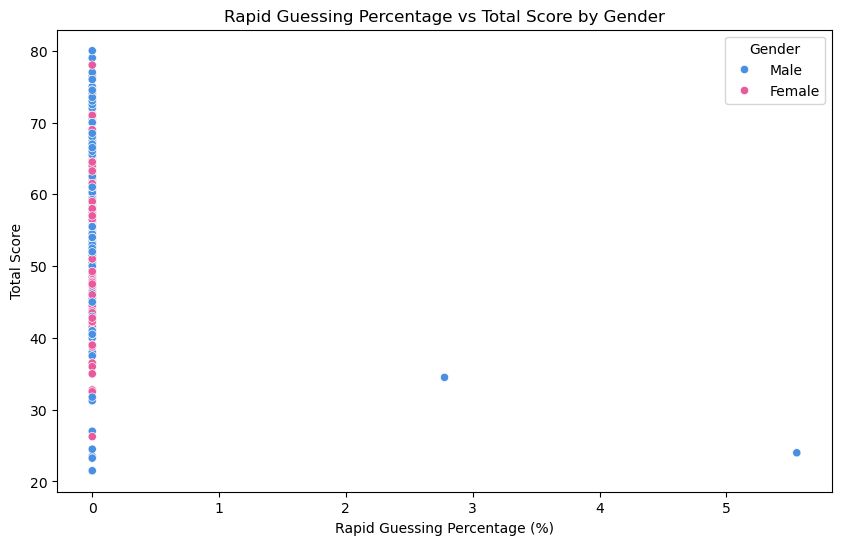

In [15]:
# how rappid guessing affects scores
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rapid_guess_results['student_stats'],
                x='rapid_guess_percentage', 
                y='total_score',
                hue='gender',
                palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
plt.title('Rapid Guessing Percentage vs Total Score by Gender')
plt.xlabel('Rapid Guessing Percentage (%)')
plt.ylabel('Total Score')

# Update legend labels for clarity - map the original labels to proper gender names
handles, labels = plt.gca().get_legend_handles_labels()
label_mapping = {'F': 'Female', 'M': 'Male'}
new_labels = [label_mapping.get(label, label) for label in labels]
plt.legend(handles, new_labels, title='Gender')

plt.show()

## Time-on-task Across the Exam (Temporal Progression)

Analyzing how students progress through the exam temporally to identify patterns such as:
- **Fatigue effects**: Do students slow down or perform worse on later items?
- **Warm-up effects**: Do students need time to get into the exam rhythm?
- **Time drift**: How does time allocation change as students progress?
- **Item placement optimization**: Are difficult items placed appropriately?

This analysis examines the sequential nature of exam-taking behavior and can reveal important insights about cognitive load, fatigue, and optimal item ordering.

In [16]:
# Prepare data for temporal progression analysis
# Calculate statistics for each question position (sequential order)
temporal_stats = df_time.groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median', 'std', 'count'],
    'auto_score_per_question': ['mean', 'std'],
    'max_question_score': 'first',
    'expected_time_per_question_sec': 'first'
}).reset_index()

# Flatten column names
temporal_stats.columns = ['question_number', 'mean_time', 'median_time', 'std_time', 'count',
                         'mean_score', 'std_score', 'max_score', 'expected_time']

# Calculate accuracy rate (percentage of max score achieved)
temporal_stats['accuracy_rate'] = (temporal_stats['mean_score'] / temporal_stats['max_score']) * 100

# Calculate time efficiency (actual vs expected)
temporal_stats['time_efficiency'] = temporal_stats['expected_time'] / temporal_stats['mean_time']
temporal_stats['time_deviation_pct'] = ((temporal_stats['mean_time'] - temporal_stats['expected_time']) / 
                                       temporal_stats['expected_time']) * 100

# Gender-specific temporal analysis
# Male
temporal_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median'],
    'auto_score_per_question': 'mean',
    'max_question_score': 'first'
}).reset_index()
temporal_male.columns = ['question_number', 'mean_time_m', 'median_time_m', 'mean_score_m', 'max_score_m']
temporal_male['accuracy_rate_m'] = (temporal_male['mean_score_m'] / temporal_male['max_score_m']) * 100

#Female
temporal_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median'],
    'auto_score_per_question': 'mean',
    'max_question_score': 'first'
}).reset_index()
temporal_female.columns = ['question_number', 'mean_time_f', 'median_time_f', 'mean_score_f', 'max_score_f']
temporal_female['accuracy_rate_f'] = (temporal_female['mean_score_f'] / temporal_female['max_score_f']) * 100

# Merge gender data for comparison
temporal_by_gender = temporal_stats.merge(temporal_male, on='question_number', how='left')
temporal_by_gender = temporal_by_gender.merge(temporal_female, on='question_number', how='left')

print("=== TEMPORAL PROGRESSION DATA PREPARED ===")
print(f"Questions analyzed: {len(temporal_stats)}")
print(f"Total student responses: {temporal_stats['count'].sum()}")
print("\nTemporal statistics:")
print(temporal_stats[['question_number', 'median_time', 'accuracy_rate', 'time_deviation_pct']].head(37))

=== TEMPORAL PROGRESSION DATA PREPARED ===
Questions analyzed: 36
Total student responses: 13176

Temporal statistics:
    question_number  median_time  accuracy_rate  time_deviation_pct
0              1.10         96.5      85.701275          -68.505237
1              1.11         64.5      89.344262          -36.467820
2              1.12        161.0      78.961749          -54.178051
3              1.13         51.0      79.690346          -83.180910
4              1.20         44.5      84.699454          -78.754933
5              1.30        241.5      42.941712          -30.786405
6              1.40         25.0      93.442623          -76.908774
7              1.50         43.0      88.979964          -86.345122
8              1.60         53.0      98.428962          -76.348095
9              1.70        228.5      27.686703          -26.839203
10             1.80         33.0      83.879781          -68.700668
11             1.90         55.0      99.726776          -47.9470

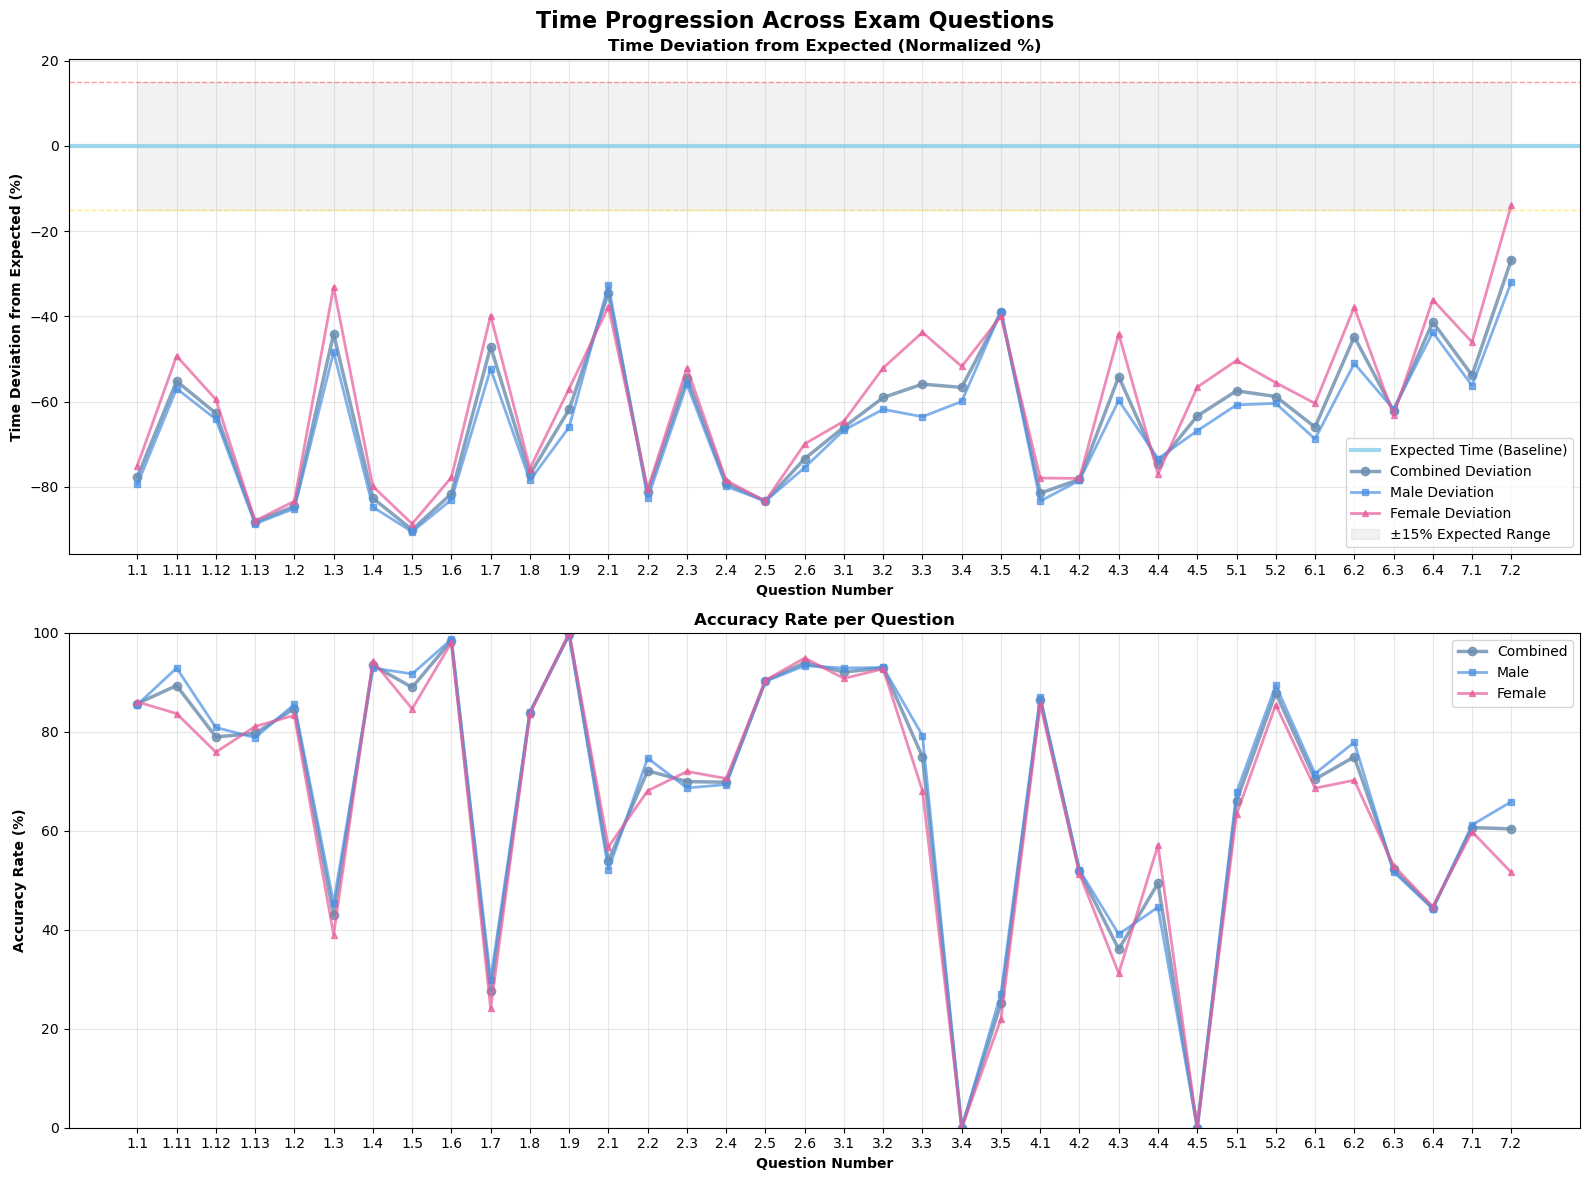

In [17]:
# 1. Time Progression Analysis: How time allocation changes across questions
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Time Progression Across Exam Questions', fontsize=16, fontweight='bold')

# Plot 1: Time Deviation from Expected (Normalized as %)
x_positions = range(len(temporal_stats))

# Calculate percentage deviations from expected time (normalized)
combined_deviation_pct = ((temporal_stats['median_time'] - temporal_stats['expected_time']) / temporal_stats['expected_time']) * 100
male_deviation_pct = ((temporal_by_gender['median_time_m'] - temporal_stats['expected_time']) / temporal_stats['expected_time']) * 100
female_deviation_pct = ((temporal_by_gender['median_time_f'] - temporal_stats['expected_time']) / temporal_stats['expected_time']) * 100

# Plot expected time as baseline (horizontal line at 0%)
line_expected = axes[0].axhline(y=0, linestyle='-', linewidth=3, 
                           color=COLOR_EXPECTED, label='Expected Time (Baseline)', alpha=0.8)

# Plot combined deviation
line1 = axes[0].plot(x_positions, combined_deviation_pct, 
                marker='o', linewidth=2.5, markersize=6, 
                color=COLOR_COMBINED, label='Combined Deviation', alpha=0.8)

# Plot gender-specific deviations
if not temporal_by_gender['median_time_m'].isna().all():
    line2 = axes[0].plot(x_positions, male_deviation_pct, 
                    marker='s', linewidth=2, markersize=5, 
                    color=COLOR_MALE, label='Male Deviation', alpha=0.7)

if not temporal_by_gender['median_time_f'].isna().all():
    line3 = axes[0].plot(x_positions, female_deviation_pct, 
                    marker='^', linewidth=2, markersize=5, 
                    color=COLOR_FEMALE, label='Female Deviation', alpha=0.7)

# Add reference lines for ±15% deviation from expected time
axes[0].fill_between(x_positions, [-15] * len(x_positions), [15] * len(x_positions), 
                alpha=0.1, color='gray', label='±15% Expected Range')

# Add horizontal reference lines
axes[0].axhline(y=15, color=COLOR_SLOW, linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhline(y=-15, color=COLOR_FAST, linestyle='--', linewidth=1, alpha=0.5)

axes[0].set_xlabel('Question Number', fontweight='bold')
axes[0].set_ylabel('Time Deviation from Expected (%)', fontweight='bold')
axes[0].set_title('Time Deviation from Expected (Normalized %)', fontweight='bold')
axes[0].set_xticks(x_positions)  # Show all question numbers
axes[0].set_xticklabels(temporal_stats['question_number'])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Accuracy Rate Progression

# Plot combined accuracy
line4 = axes[1].plot(x_positions, temporal_stats['accuracy_rate'], 
                marker='o', linewidth=2.5, markersize=6, 
                color=COLOR_COMBINED, label='Combined', alpha=0.8)

# Plot gender-specific accuracy
if not temporal_by_gender['accuracy_rate_m'].isna().all():
    line5 = axes[1].plot(x_positions, temporal_by_gender['accuracy_rate_m'], 
                    marker='s', linewidth=2, markersize=5, 
                    color=COLOR_MALE, label='Male', alpha=0.7)

if not temporal_by_gender['accuracy_rate_f'].isna().all():
    line6 = axes[1].plot(x_positions, temporal_by_gender['accuracy_rate_f'], 
                    marker='^', linewidth=2, markersize=5, 
                    color=COLOR_FEMALE, label='Female', alpha=0.7)

axes[1].set_xlabel('Question Number', fontweight='bold')
axes[1].set_ylabel('Accuracy Rate (%)', fontweight='bold')
axes[1].set_title('Accuracy Rate per Question', fontweight='bold')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(temporal_stats['question_number'])
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Understanding the Time vs Accuracy Relationship

**What This Chart Shows:**
The next chart is like a map showing the relationship between two important things:
- **How much time students spend** on each question (horizontal axis)
- **How well they perform** on each question (vertical axis - percentage correct)

**How to Read This Chart:**
- Each dot represents one question from the exam
- **Position left/right**: Questions on the left took less time, questions on the right took more time
- **Position up/down**: Questions higher up had better accuracy (students got them right more often)
- **Color of dots**: Shows question difficulty - yellow colors mean harder questions (worth more points)
- **Red dashed line**: Shows the general trend - does spending more time generally lead to better performance?

**What We're Looking For:**
- Do harder questions (yellow dots) tend to take more time?
- Is there a relationship between time spent and accuracy?
- Are there any "outlier" questions that don't fit the pattern?

**Real-World Meaning:**
This helps us understand if the exam is well-designed - ideally, students should have enough time to demonstrate their knowledge, but not so much that time becomes irrelevant to performance.

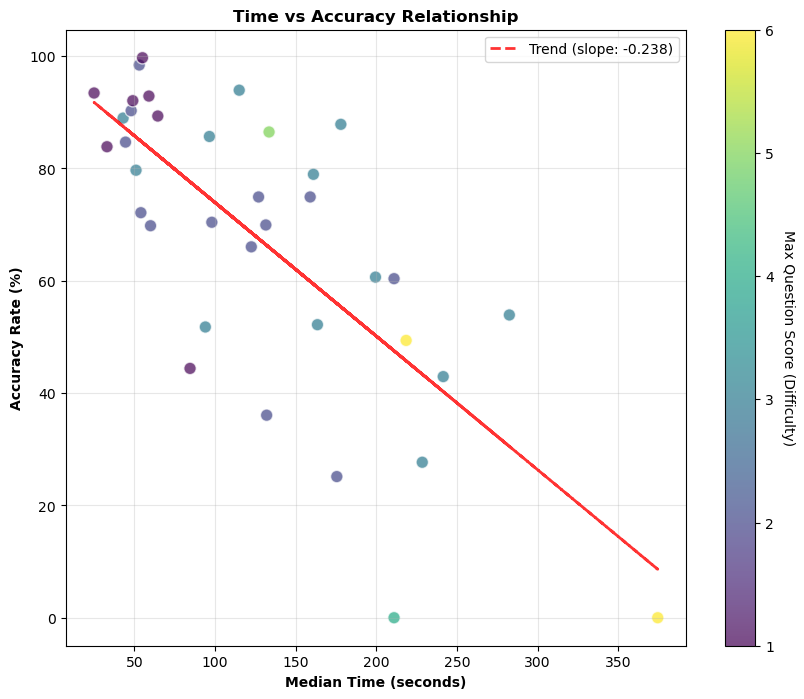


=== UNDERSTANDING THE TREND LINE ===
Trend slope value: -0.2379
 NEGATIVE RELATIONSHIP (Strong)
• When students spend MORE time on questions, they tend to get LOWER accuracy
• This could mean students are struggling with harder questions (taking more time but still getting them wrong)
• Or it might suggest that overthinking hurts performance


In [18]:
# Plot: Time vs Accuracy Relationship (Scatterplot)
plt.figure(figsize=(10, 8))

# Create scatter plot with color mapping based on question difficulty (max score)
scatter = plt.scatter(temporal_stats['median_time'], temporal_stats['accuracy_rate'],
                     c=temporal_stats['max_score'], s=80, alpha=0.7, 
                     cmap='viridis', edgecolor='white', linewidth=1)

# Add colorbar for question difficulty
cbar = plt.colorbar(scatter)
cbar.set_label('Max Question Score (Difficulty)', rotation=270, labelpad=15)

# Add trend line
z = np.polyfit(temporal_stats['median_time'], temporal_stats['accuracy_rate'], 1)
p = np.poly1d(z)
plt.plot(temporal_stats['median_time'], p(temporal_stats['median_time']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend (slope: {z[0]:.3f})')

plt.xlabel('Median Time (seconds)', fontweight='bold')
plt.ylabel('Accuracy Rate (%)', fontweight='bold')
plt.title('Time vs Accuracy Relationship', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Interpret the trend slope for easy understanding
print("\n=== UNDERSTANDING THE TREND LINE ===")
slope = z[0]
print(f"Trend slope value: {slope:.4f}")

if slope > 0.1:
    print(" POSITIVE RELATIONSHIP (Strong)")
    print("• When students spend MORE time on questions, they tend to get HIGHER accuracy")
    print("• This suggests that taking more time helps students perform better")
    print("• The exam might benefit from allowing more thinking time")
elif slope > 0.01:
    print(" POSITIVE RELATIONSHIP (Weak)")
    print("• When students spend more time, they tend to get slightly higher accuracy")
    print("• There's a small benefit to taking more time, but it's not very strong")
    print("• Time allocation seems reasonably appropriate")
elif slope < -0.1:
    print(" NEGATIVE RELATIONSHIP (Strong)")
    print("• When students spend MORE time on questions, they tend to get LOWER accuracy")
    print("• This could mean students are struggling with harder questions (taking more time but still getting them wrong)")
    print("• Or it might suggest that overthinking hurts performance")
elif slope < -0.01:
    print(" NEGATIVE RELATIONSHIP (Weak)")
    print("• When students spend more time, they tend to get slightly lower accuracy")
    print("• This might indicate some questions are confusing or poorly designed")
    print("• Students who spend more time aren't necessarily performing better")
else:
    print(" NO CLEAR RELATIONSHIP")
    print("• Time spent and accuracy are not clearly related")
    print("• This could mean the exam is well-balanced - neither rushed nor too lengthy")
    print("• Performance depends more on knowledge than time management")

### Universal Fatigue Detection Analysis

This analysis uses a **universal grouping approach** that automatically adapts to different question numbering conventions:

**Float Format (e.g., 1.1, 1.2, 2.1, 2.2, 3.1, 3.2)**
- **Method**: Groups questions by part number (integer portion)
- **Example**: Part 1 = (1.1, 1.2, 1.3...), Part 2 = (2.1, 2.2, 2.3...), etc.
- **Advantage**: Respects the natural exam structure and intended groupings

**Integer Format (e.g., 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)**
- **Method**: Divides exam into 5 equal segments (20% each)
- **Example**: Segment 1 = (1-20%), Segment 2 = (21-40%), etc.
- **Advantage**: Creates balanced groups for temporal progression analysis

This approach ensures consistent and meaningful analysis across different exam formats while maintaining the ability to detect fatigue patterns, warm-up effects, and performance changes throughout the exam.

=== UNIVERSAL FATIGUE ANALYSIS ===
Grouping method: Part-based grouping (float format)

Segment Analysis:
   segment description question_range  question_count  avg_time  accuracy_rate
0        1      Part 1      Q1.1-Q1.9              12    121.23          74.79
1        2      Part 2      Q2.1-Q2.6               6    144.81          74.85
2        3      Part 3      Q3.1-Q3.5               5    197.92          32.09
3        4      Part 4      Q4.1-Q4.5               5    205.50          47.81
4        5      Part 5      Q5.1-Q5.2               2    191.28          79.14
5        6      Part 6      Q6.1-Q6.4               4    160.66          61.46
6        7      Part 7      Q7.1-Q7.2               2    264.31          60.55


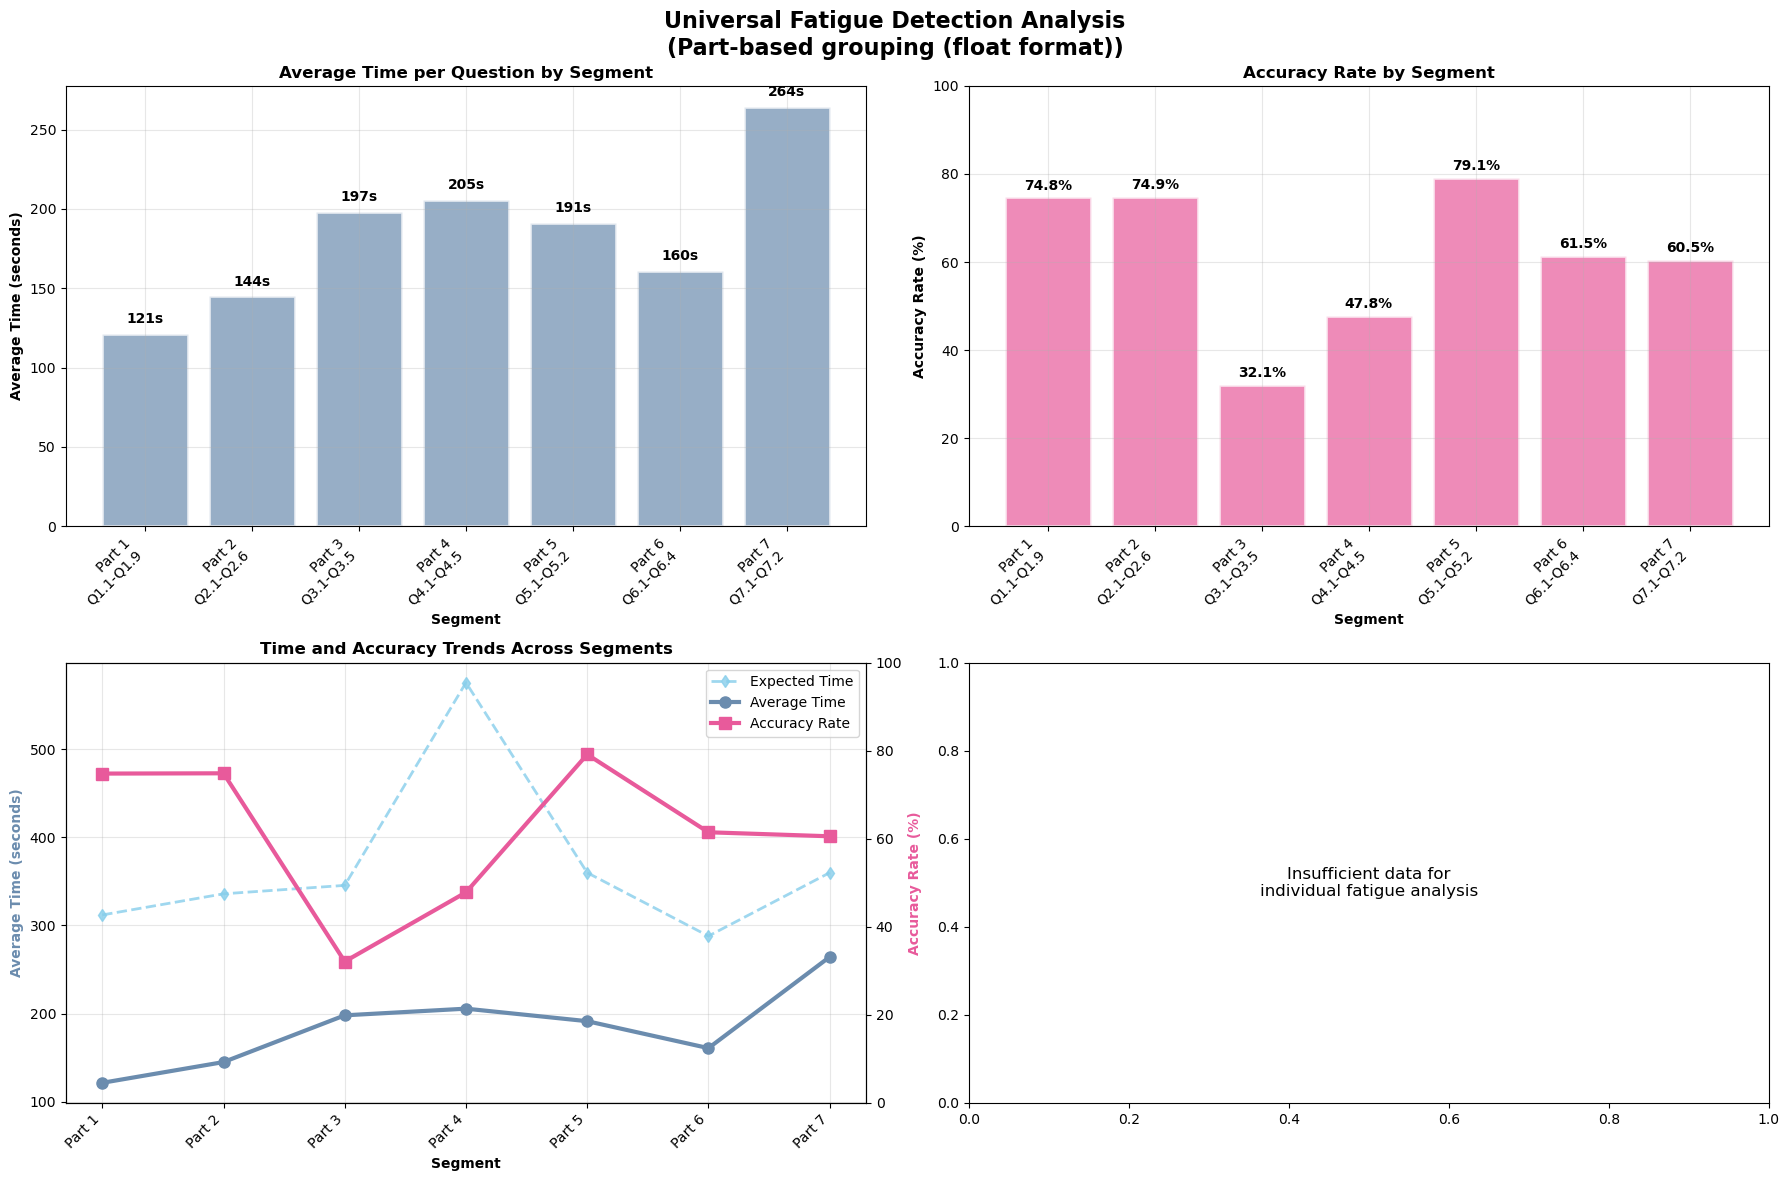


=== FATIGUE PATTERN SUMMARY ===
Grouping Method: Part-based grouping (float format)
Total segments analyzed: 7
Time change from first to last segment: 143.1 seconds
Accuracy change from first to last segment: -14.24%
• Time trend: Students are taking significantly longer on later segments (possible fatigue)
• Accuracy trend: Performance declines in later segments (fatigue effect detected)
Individual fatigue analysis could not be performed (insufficient segment data)


In [19]:
# Universal Fatigue Detection Analysis
# Analyze if students perform worse on later items by creating groups based on question naming convention
# - For float questions (1.1, 1.2, 2.1, 2.2, etc.): Group by part number (integer portion)
# - For integer questions (1, 2, 3, 4, etc.): Divide into 5 equal parts (20% each)

def analyze_fatigue_patterns_universal(df_time, n_segments_for_integer=5):
    """
    Universal fatigue pattern analysis that adapts to different question numbering schemes.
    
    Parameters:
    -----------
    df_time : DataFrame
        The exam data with question_number column
    n_segments_for_integer : int, default=5
        Number of segments to create for integer-numbered questions (20% each)
    
    Returns:
    --------
    tuple : (segment_df, segments, grouping_method)
        - segment_df: DataFrame with statistics for each segment
        - segments: List of segment information
        - grouping_method: String describing the grouping method used
    """
    # Get unique question numbers and sort them
    questions = sorted(df_time['question_number'].unique())
    total_questions = len(questions)
    
    # Determine if questions use float format (parts) or integer format
    has_decimals = any(q != int(q) for q in questions if isinstance(q, (int, float)))
    
    if has_decimals:
        # Float format: Group by part number (1.1, 1.2 -> Part 1; 2.1, 2.2 -> Part 2, etc.)
        grouping_method = "Part-based grouping (float format)"
        
        # Extract unique parts
        parts = [int(q) for q in questions]
        unique_parts = sorted(set(parts))
        
        # Create segments based on parts
        segments = []
        for i, part in enumerate(unique_parts):
            part_questions = [q for q in questions if int(q) == part]
            segments.append({
                'segment': i + 1,
                'part_number': part,
                'questions': part_questions,
                'start_q': part_questions[0],
                'end_q': part_questions[-1],
                'question_count': len(part_questions),
                'description': f"Part {part}"
            })
    else:
        # Integer format: Divide into equal segments
        grouping_method = f"Equal division into {n_segments_for_integer} segments (integer format)"
        
        segment_size = total_questions // n_segments_for_integer
        segments = []
        
        for i in range(n_segments_for_integer):
            start_idx = i * segment_size
            if i == n_segments_for_integer - 1:  # Last segment includes remaining questions
                end_idx = total_questions
            else:
                end_idx = (i + 1) * segment_size
            
            segment_questions = questions[start_idx:end_idx]
            segments.append({
                'segment': i + 1,
                'part_number': None,  # No part concept for integer questions
                'questions': segment_questions,
                'start_q': segment_questions[0],
                'end_q': segment_questions[-1],
                'question_count': len(segment_questions),
                'description': f"Segment {i + 1} ({(i*100//n_segments_for_integer) + 1}-{((i+1)*100//n_segments_for_integer)}%)"
            })
    
    # Calculate statistics for each segment
    segment_stats = []
    for segment in segments:
        segment_data = df_time[df_time['question_number'].isin(segment['questions'])]
        
        stats = {
            'segment': segment['segment'],
            'description': segment['description'],
            'question_range': f"Q{segment['start_q']}-Q{segment['end_q']}",
            'question_count': segment['question_count'],
            'avg_time': segment_data['question_duration_sec'].mean(),
            'median_time': segment_data['question_duration_sec'].median(),
            'avg_score': segment_data['auto_score_per_question'].mean(),
            'avg_max_score': segment_data['max_question_score'].mean(),
            'student_count': segment_data['student_id'].nunique(),
            'total_responses': len(segment_data)
        }
        
        # Calculate accuracy rate using total points earned / total points possible
        stats['accuracy_rate'] = (stats['avg_score'] / stats['avg_max_score']) * 100
        
        segment_stats.append(stats)
    
    segment_df = pd.DataFrame(segment_stats)
    return segment_df, segments, grouping_method

# Perform universal fatigue analysis
fatigue_stats, exam_segments, grouping_method = analyze_fatigue_patterns_universal(df_time)

print("=== UNIVERSAL FATIGUE ANALYSIS ===")
print(f"Grouping method: {grouping_method}")
print("\nSegment Analysis:")
display_columns = ['segment', 'description', 'question_range', 'question_count', 'avg_time', 'accuracy_rate']
print(fatigue_stats[display_columns].round(2))

# Create enhanced fatigue visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Universal Fatigue Detection Analysis\n({grouping_method})', 
             fontsize=16, fontweight='bold')

# Plot 1: Average Time by Segment
ax1 = axes[0, 0]
bars1 = ax1.bar(fatigue_stats['segment'], fatigue_stats['avg_time'], 
                color=COLOR_COMBINED, alpha=0.7, edgecolor='white', linewidth=2)
ax1.set_xlabel('Segment', fontweight='bold')
ax1.set_ylabel('Average Time (seconds)', fontweight='bold')
ax1.set_title('Average Time per Question by Segment', fontweight='bold')
ax1.set_xticks(fatigue_stats['segment'])

# Create labels for x-axis based on grouping method
x_labels = []
for _, row in fatigue_stats.iterrows():
    if "Part" in row['description']:
        x_labels.append(f"{row['description']}\n{row['question_range']}")
    else:
        x_labels.append(f"{row['description']}\n{row['question_range']}")

ax1.set_xticklabels(x_labels, rotation=45 if len(x_labels) > 4 else 0, ha='right' if len(x_labels) > 4 else 'center')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}s', ha='center', va='bottom', fontweight='bold')

# Plot 2: Accuracy Rate by Segment
ax2 = axes[0, 1]
bars2 = ax2.bar(fatigue_stats['segment'], fatigue_stats['accuracy_rate'], 
                color=COLOR_FEMALE, alpha=0.7, edgecolor='white', linewidth=2)
ax2.set_xlabel('Segment', fontweight='bold')
ax2.set_ylabel('Accuracy Rate (%)', fontweight='bold')
ax2.set_title('Accuracy Rate by Segment', fontweight='bold')
ax2.set_xticks(fatigue_stats['segment'])
ax2.set_xticklabels(x_labels, rotation=45 if len(x_labels) > 4 else 0, ha='right' if len(x_labels) > 4 else 'center')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: Combined Time and Accuracy Trends
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()

# Calculate average expected time per segment
expected_time_per_segment = []
for segment in exam_segments:
    segment_data = df_time[df_time['question_number'].isin(segment['questions'])]
    avg_expected_time = segment_data['expected_time_per_question_sec'].mean()
    expected_time_per_segment.append(avg_expected_time)

# Plot expected time trend (light blue line)
line_expected = ax3.plot(fatigue_stats['segment'], expected_time_per_segment, 
                        marker='d', linewidth=2, markersize=6, 
                        color='#87CEEB', label='Expected Time', alpha=0.8, linestyle='--')

# Plot actual time trend
line1 = ax3.plot(fatigue_stats['segment'], fatigue_stats['avg_time'], 
                marker='o', linewidth=3, markersize=8, 
                color=COLOR_COMBINED, label='Average Time')

# Plot accuracy trend on secondary y-axis
line2 = ax3_twin.plot(fatigue_stats['segment'], fatigue_stats['accuracy_rate'], 
                     marker='s', linewidth=3, markersize=8, 
                     color=COLOR_FEMALE, label='Accuracy Rate')

ax3.set_xlabel('Segment', fontweight='bold')
ax3.set_ylabel('Average Time (seconds)', color=COLOR_COMBINED, fontweight='bold')
ax3_twin.set_ylabel('Accuracy Rate (%)', color=COLOR_FEMALE, fontweight='bold')
ax3_twin.set_ylim(0, 100)
ax3.set_title('Time and Accuracy Trends Across Segments', fontweight='bold')
ax3.set_xticks(fatigue_stats['segment'])
ax3.set_xticklabels([row['description'] for _, row in fatigue_stats.iterrows()], 
                   rotation=45 if len(fatigue_stats) > 4 else 0, 
                   ha='right' if len(fatigue_stats) > 4 else 'center')
ax3.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Plot 4: Individual Student Fatigue Patterns (ALL STUDENTS)
ax4 = axes[1, 1]

# Calculate individual student performance decline
student_fatigue = []
all_students = df_time['student_id'].unique()  # Changed: Use ALL students instead of [:20]

for student_id in all_students:  # Changed: Analyze all students
    student_data = df_time[df_time['student_id'] == student_id].sort_values('question_number')
    if len(student_data) >= len(exam_segments):  # Ensure sufficient data across segments
        
        # For part-based grouping, compare first part vs last part
        if len(exam_segments) <= 5:  # Reasonable number of segments
            first_segment_questions = exam_segments[0]['questions']
            last_segment_questions = exam_segments[-1]['questions']
            
            first_segment_data = student_data[student_data['question_number'].isin(first_segment_questions)]
            last_segment_data = student_data[student_data['question_number'].isin(last_segment_questions)]
            
            if len(first_segment_data) > 0 and len(last_segment_data) > 0:
                first_accuracy = (first_segment_data['auto_score_per_question'].sum() / 
                                first_segment_data['max_question_score'].sum()) * 100
                last_accuracy = (last_segment_data['auto_score_per_question'].sum() / 
                               last_segment_data['max_question_score'].sum()) * 100
                
                fatigue_score = last_accuracy - first_accuracy  # Positive = improvement
                student_fatigue.append(fatigue_score)

# Create histogram of fatigue scores
if len(student_fatigue) > 0:
    ax4.hist(student_fatigue, bins=20, color=COLOR_MALE, alpha=0.7,  # Changed: More bins for better distribution
             edgecolor='white', linewidth=1)
    ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, 
               label='No change')
    ax4.set_xlabel('Performance Change (Last - First Segment %)', fontweight='bold')
    ax4.set_ylabel('Number of Students', fontweight='bold')
    ax4.set_title(f'Distribution of Individual Fatigue Patterns (n={len(student_fatigue)})', fontweight='bold')  # Changed: Show actual count
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Add text annotation with clearer labels
    improvement_count = sum(1 for score in student_fatigue if score > 5)
    decline_count = sum(1 for score in student_fatigue if score < -5)
    ax4.text(0.02, 0.98, f'Students showing improvement (positive values >5%): {improvement_count}\nStudents showing decline (negative values <-5%): {decline_count}', 
             transform=ax4.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    ax4.text(0.5, 0.5, 'Insufficient data for\nindividual fatigue analysis', 
             transform=ax4.transAxes, ha='center', va='center', fontsize=12)
    decline_count = 0
    improvement_count = 0

plt.tight_layout()
plt.show()

# Print enhanced statistical analysis
print(f"\n=== FATIGUE PATTERN SUMMARY ===")
print(f"Grouping Method: {grouping_method}")
print(f"Total segments analyzed: {len(fatigue_stats)}")

if len(fatigue_stats) >= 2:
    time_change = fatigue_stats.iloc[-1]['avg_time'] - fatigue_stats.iloc[0]['avg_time']
    accuracy_change = fatigue_stats.iloc[-1]['accuracy_rate'] - fatigue_stats.iloc[0]['accuracy_rate']
    
    print(f"Time change from first to last segment: {time_change:.1f} seconds")
    print(f"Accuracy change from first to last segment: {accuracy_change:.2f}%")
    
    # Interpretation
    if time_change > 30:
        print("• Time trend: Students are taking significantly longer on later segments (possible fatigue)")
    elif time_change < -30:
        print("• Time trend: Students are taking less time on later segments (possible rushing/giving up)")
    else:
        print("• Time trend: Relatively stable time allocation across segments")
        
    if accuracy_change < -5:
        print("• Accuracy trend: Performance declines in later segments (fatigue effect detected)")
    elif accuracy_change > 5:
        print("• Accuracy trend: Performance improves in later segments (warm-up effect)")
    else:
        print("• Accuracy trend: Stable performance across segments")

if len(student_fatigue) > 0:
    print(f"Students showing performance improvement (positive values): {improvement_count}/{len(all_students)} ({improvement_count/len(all_students)*100:.1f}%)")
    print(f"Students showing performance decline (negative values): {decline_count}/{len(all_students)} ({decline_count/len(all_students)*100:.1f}%)")
    print("\nNote: In this analysis:")
    print("• Positive values = Performance improved from first to last segment")
    print("• Negative values = Performance declined from first to last segment")
    print("• Zero = No change between first and last segments")
else:
    print("Individual fatigue analysis could not be performed (insufficient segment data)")